# AI Agent 이해와 주요 구성요소

**AI Agent**
- 스스로 의사 결정하며, 도구를 사용하여, 목표를 달성하는 시스템 → 문제를 스스로 해결하는 시스템
    - 도구 사용이나 다단계 추론을 활용
    - LLM을 중심으로 다양한 외부 도구를 연결하여 구축

**주요 구성 요소**

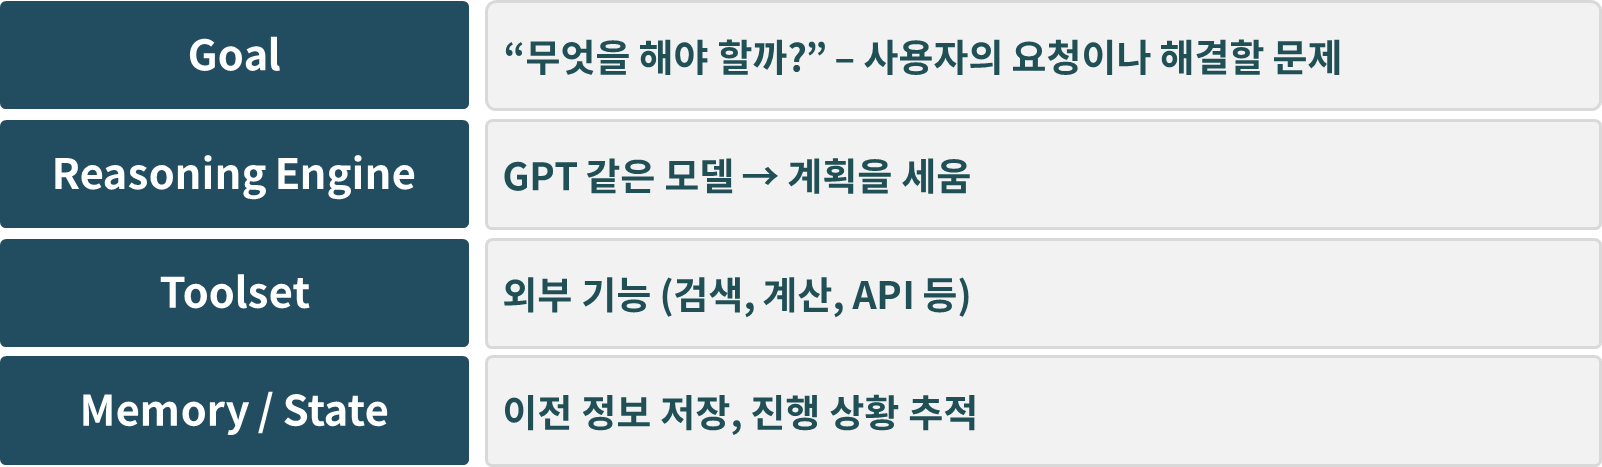

**LangGraph**
- AI Agent 간의 협업을 그래프 기반으로 설계하는 프레임워크
- 워크플로우(Workflow) : AI 에이전트들이 특정 목표를 위해 수행하는 일련의 과정 의미
- 복잡한 워크플로우를 처리하기 위해 그래프 구조가 필요.

**구성요소**
- 노드(Node)
    - 노드는 그래프에서 특정 작업이나 판단을 수행하는 단위를 의미
    - 각 노드는 파이썬 함수나 객체의 call 메서드로 구현
    - 예를 들어, 사용자의 질문을 이해하거나 필요한 정보를 검색하는 등의 작업을 담당
- 엣지(Edge)
    - 엣지는 노드 간의 연결을 나타내며, 작업의 흐름을 정의
    - 즉, 한 노드의 작업이 완료된 후 어떤 노드로 이동할지를 결정하는 역할
- 조건부 엣지(Conditional Edge)
    - 조건부 엣지는 특정 조건에 따라 노드 간의 분기 처리를 가능하게 함
    - 예를 들어, 특정 조건이 충족되면 A 노드에서 B 노드로 이동하고, 그렇지 않으면 C 노드로 이동
- 스테이트(State)
    - 스테이트는 그래프의 현재 상태 값을 저장 및 전달하는 역할
    - 대화 이력, 수집한 정보, 중간 결과 등을 포함
    - 각 노드는 이 state를 입력으로 받아 처리한 후 업데이트

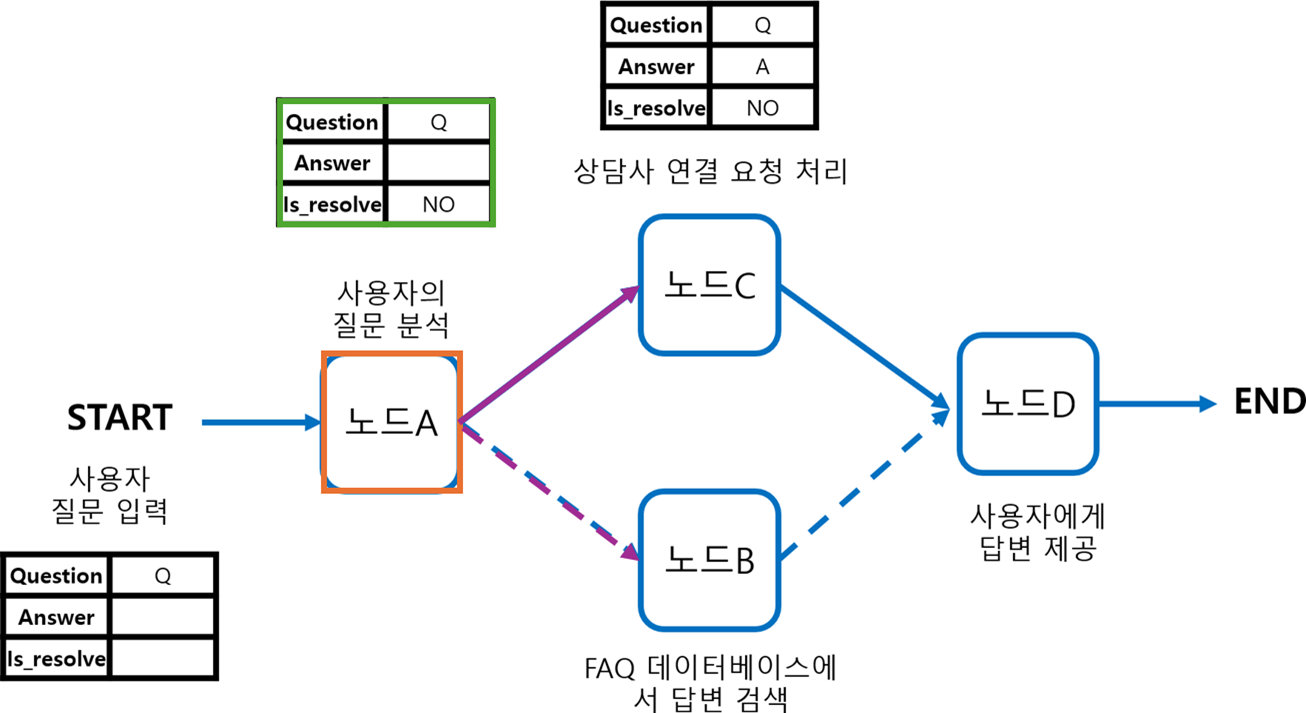



## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(LangGraph)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리

#### 1) 필요한 라이브러리 설치
* 설치 후 세션 다시 시작

In [2]:
!pip install langchain langgraph typing typing_extensions langchain-openai langchain_core langchain-community -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.8/449.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/207.6 kB 14.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency confli

#### 2) 라이브러리 로딩

In [3]:
import pandas as pd
import numpy as np
import os
import openai
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### (3) OpenAI API Key 확인

In [4]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/LangGraph/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

* ⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [5]:
print(os.environ['OPENAI_API_KEY'][:40])

sk-proj-9_V5Db5A_3EzpkFeDNheztR-ns32fKi-


## 2.Graph 구축① : 간단한 그래프

### (1) 간단한 그래프

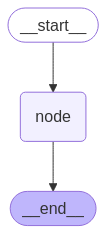

#### 1) State 정의
- 그래프의 노드의 입력과 출력 관리하는 딕셔너리 형태의 자료형
- 그래프를 통과하며, 컨텍스트를 유지 (각 노드는 입력과 출력을 State에 담아 처리)
- typing 모듈의 TypedDict 클래스를 사용.


In [6]:
from typing import TypedDict

# 그래프 전체에서 주고받는 데이터 구조를 정의
class State(TypedDict):
    text: str
    extra_field: int

#### 2) Node 정의
- 입력 : State 구조
- 출력 : State 구조


In [7]:
def node_1(state: State):
    print(state)
    # 입력: 상태 (state) → text 필드에 문자열을 덧붙임
    # extra_field은 무조건 10으로 덮어씀
    return {"text": state['text'] + "(텍스트 추가됨)", "extra_field": 10}

#### 3) 그래프 정의

In [8]:
from langgraph.graph import StateGraph, START, END

# 그래프 초기화
builder = StateGraph(State)

# Node 추가
builder.add_node("node", node_1)  # "node"라는 이름으로 node_1 함수를 노드로 추가

# 노드 연결
builder.add_edge(START, "node")
builder.add_edge("node", END)

# 그래프 컴파일
graph = builder.compile()

* 그래프 시각화

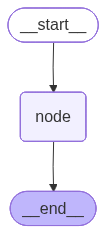

In [9]:
from IPython.display import Image, display

# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

* 만약 오류가 계속 발생된다면 아래 코드 수행

In [10]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node(node)
	__end__([<p>__end__</p>]):::last
	__start__ --> node;
	node --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



* 위 결과를 https://mermaid.live 에 붙여넣기

#### 4) Graph 실행
- 입력 : State 딕셔너리 형식. 특정 키만 입력 가능
- 출력 : State 딕셔너리 형식.


In [11]:
graph.invoke({"text" : "안녕!"})

{'text': '안녕!'}


{'text': '안녕!(텍스트 추가됨)', 'extra_field': 10}

### (2) 실습1

다음과 같은 그래프를 구축해 봅시다.
* node_1 : 위 함수 그대로 사용 가능
* node_2 : node_1을 그대로 사용해도 되고, 조금 변형해도 됨.

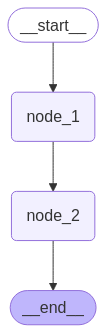

* State 정의  
(직접 코딩해 봅시다.)

In [12]:
class State(TypedDict):
    text: str
    extra_field: int

* Node 정의

In [13]:
# 노드 1: 텍스트에 문장 추가 + 필드 값 고정
def node_1(state: State):
    print("node_1 실행 전:", state)

    new_state = {
        "text": state["text"] + " → node_1에서 추가됨",
        "extra_field": 10
    }

    print("node_1 실행 후:", new_state)
    return new_state

# 노드 2: 텍스트에 추가 + 필드 증가
def node_2(state: State):
    print("node_2 실행 전:", state)

    new_state = {
        "text": state["text"] + " → node_2까지 통과",
        "extra_field": state["extra_field"] + 5
    }

    print("node_2 실행 후:", new_state)
    return new_state

* 그래프 정의  
(직접 코딩해 봅시다.)


In [14]:
# 그래프 생성
builder = StateGraph(State)

# 노드 등록
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# 엣지 연결: START → node_1 → node_2 → END
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# 그래프 컴파일
graph = builder.compile()

* 그래프 시각화

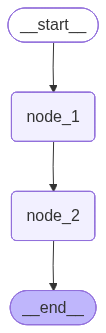

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

* Graph 실행

In [16]:
# 실행
initial_state = {"text": "처음 시작", "extra_field": 0}

result = graph.invoke(initial_state)
print("최종 결과:", result)

node_1 실행 전: {'text': '처음 시작', 'extra_field': 0}
node_1 실행 후: {'text': '처음 시작 → node_1에서 추가됨', 'extra_field': 10}
node_2 실행 전: {'text': '처음 시작 → node_1에서 추가됨', 'extra_field': 10}
node_2 실행 후: {'text': '처음 시작 → node_1에서 추가됨 → node_2까지 통과', 'extra_field': 15}
최종 결과: {'text': '처음 시작 → node_1에서 추가됨 → node_2까지 통과', 'extra_field': 15}


### (3) 실습2

* 입력값에 연산을 반복 적용하는 단방향 그래프를 만들어보자.
* 사용자로부터 숫자 하나를 입력받아, 다음 연산을 순서대로 수행하는 그래프(아래 그래프)를 구현하시오
    * 각 연산은 독립된 노드로 만들기 (double, square, add_five)
    * 최종 결과는 result 노드에서 출력되도록 구성
    * 상태 구조: {"value": 입력값} 형식 유지


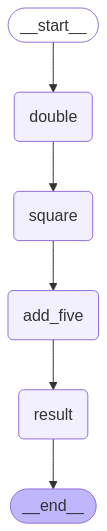

* State 정의  
(직접 코딩해 봅시다.)

In [17]:
# 1. 상태 정의
from typing import TypedDict

class NumberState(TypedDict):
    value: int

* 노드 정의

In [18]:
# 2. 노드 정의
def double_node(state: NumberState) -> NumberState:
    state["value"] *= 2
    print(f"[Double] => {state['value']}")
    return state

def square_node(state: NumberState) -> NumberState:
    state["value"] = state["value"] ** 2
    print(f"[Square] => {state['value']}")
    return state

def add_five_node(state: NumberState) -> NumberState:
    state["value"] += 5
    print(f"[Add 5] => {state['value']}")
    return state

def result_node(state: NumberState) -> NumberState:
    print(f"[Result] 최종 결과는 {state['value']}입니다.")
    return state

* 그래프 정의

In [19]:
# 3. 그래프 정의
builder = StateGraph(NumberState)

builder.add_node("double", double_node)
builder.add_node("square", square_node)
builder.add_node("add_five", add_five_node)
builder.add_node("result", result_node)

# 노드 연결
builder.set_entry_point("double")
builder.add_edge("double", "square")
builder.add_edge("square", "add_five")
builder.add_edge("add_five", "result")
builder.add_edge("result", END)

# 그래프 빌드
graph = builder.compile()

* 그래프 시각화

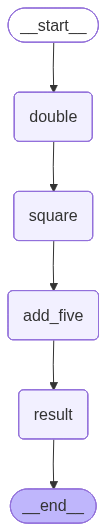

In [20]:
# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

* 실행

In [21]:
# 4. 실행
input_value = int(input("숫자를 입력하세요: "))
initial_state = {"value": input_value}
graph.invoke(initial_state)

숫자를 입력하세요: 25
[Double] => 50
[Square] => 2500
[Add 5] => 2505
[Result] 최종 결과는 2505입니다.


{'value': 2505}

## 3.State 다루기

### (1) State 값 변화

* 노드 2개: START → node_1 → node_2 → END
* State 필드 4개 사용
    * text: 누적 메시지 기록
    * user_id: 사용자 고유 ID
    * step: 현재 몇 번째 노드인지
    * history: 각 노드 처리 기록 저장 (리스트)

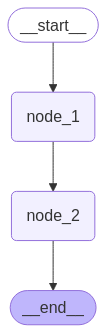

#### 1) State 정의

In [22]:
class State(TypedDict):
    text: str
    user_id: str
    step: int
    history: list[str]

#### 2) Node 정의

In [23]:
# node_1: 텍스트 변경 + step 증가 + 기록 저장
def node_1(state: State):
    print("node_1 실행 전 상태:", state)

    state["text"] += " → node_1 처리 완료"
    state["step"] += 1
    state["history"].append(f"node_1 완료 (step  {state['step']})")

    print("node_1 실행 후 상태:", state)
    return state

# node_2: 또 한 번 수정 + 기록 누적
def node_2(state: State):
    print("node_2 실행 전 상태:", state)

    state["text"] += " → node_2 처리 완료"
    state["step"] += 1
    state["history"].append(f"node_2 완료 (step {state['step']})")

    print("node_2 실행 후 상태:", state)
    return state

#### 3) 그래프 정의

In [24]:
# 그래프 구성
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

graph = builder.compile()

* 그래프 시각화

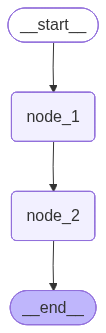

In [25]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) Graph 실행

In [26]:
# 실행 : 함수로 실행
initial_state = {
    "text": "처음 요청 도착",
    "user_id": "user_1234",
    "step": 0,
    "history": []
}

# node_1
state = node_1(initial_state)
print(f'node_1 : {state}')

# node_1
state = node_2(state)
print(f'node_2 : {state}')

node_1 실행 전 상태: {'text': '처음 요청 도착', 'user_id': 'user_1234', 'step': 0, 'history': []}
node_1 실행 후 상태: {'text': '처음 요청 도착 → node_1 처리 완료', 'user_id': 'user_1234', 'step': 1, 'history': ['node_1 완료 (step  1)']}
node_1 : {'text': '처음 요청 도착 → node_1 처리 완료', 'user_id': 'user_1234', 'step': 1, 'history': ['node_1 완료 (step  1)']}
node_2 실행 전 상태: {'text': '처음 요청 도착 → node_1 처리 완료', 'user_id': 'user_1234', 'step': 1, 'history': ['node_1 완료 (step  1)']}
node_2 실행 후 상태: {'text': '처음 요청 도착 → node_1 처리 완료 → node_2 처리 완료', 'user_id': 'user_1234', 'step': 2, 'history': ['node_1 완료 (step  1)', 'node_2 완료 (step 2)']}
node_2 : {'text': '처음 요청 도착 → node_1 처리 완료 → node_2 처리 완료', 'user_id': 'user_1234', 'step': 2, 'history': ['node_1 완료 (step  1)', 'node_2 완료 (step 2)']}


In [27]:
# 실행 : graph로 실행
initial_state = {
    "text": "처음 요청 도착",
    "user_id": "user_1234",
    "step": 0,
    "history": []
}

result = graph.invoke(initial_state)
print("\n 최종 결과 상태:", result)

node_1 실행 전 상태: {'text': '처음 요청 도착', 'user_id': 'user_1234', 'step': 0, 'history': []}
node_1 실행 후 상태: {'text': '처음 요청 도착 → node_1 처리 완료', 'user_id': 'user_1234', 'step': 1, 'history': ['node_1 완료 (step  1)']}
node_2 실행 전 상태: {'text': '처음 요청 도착 → node_1 처리 완료', 'user_id': 'user_1234', 'step': 1, 'history': ['node_1 완료 (step  1)']}
node_2 실행 후 상태: {'text': '처음 요청 도착 → node_1 처리 완료 → node_2 처리 완료', 'user_id': 'user_1234', 'step': 2, 'history': ['node_1 완료 (step  1)', 'node_2 완료 (step 2)']}

 최종 결과 상태: {'text': '처음 요청 도착 → node_1 처리 완료 → node_2 처리 완료', 'user_id': 'user_1234', 'step': 2, 'history': ['node_1 완료 (step  1)', 'node_2 완료 (step 2)']}


### (2) 실습1
유저 프로필 정보 누적 저장
* 요구사항
    * 그래프 : start → 이름 입력 → 나이 입력 → 이메일 입력 → 출력
        * 유저의 이름, 나이, 이메일 정보를 순차적으로 입력받아 상태(State)에 저장하는 과정을 연습하자.
    * 조건
        * 상태 구조는 {"name": str, "age": int, "email": str}
        * 각 노드는 입력값을 받아 상태에 반영
        * 최종 출력 노드에서 전체 상태를 출력할 것

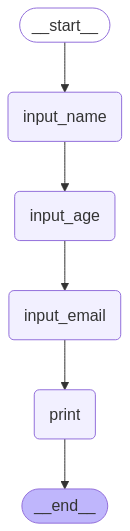

* 1) State 정의

In [28]:
class ProfileState(TypedDict):
    name: str
    age: int
    email: str

* 2) Node 정의

In [29]:
def input_name(state: ProfileState) -> ProfileState:
    name = input("이름을 입력하세요: ")
    state["name"] = name
    return state

def input_age(state: ProfileState) -> ProfileState:
    age = int(input("나이를 입력하세요: "))
    state["age"] = age
    return state

def input_email(state: ProfileState) -> ProfileState:
    email = input("이메일을 입력하세요: ")
    state["email"] = email
    return state

def print_profile(state: ProfileState) -> ProfileState:
    print("\n[유저 프로필 정보]")
    print(f"이름: {state['name']}")
    print(f"나이: {state['age']}")
    print(f"이메일: {state['email']}")
    return state

* 3) 그래프 정의

In [30]:
builder = StateGraph(ProfileState)

builder.add_node("input_name", input_name)
builder.add_node("input_age", input_age)
builder.add_node("input_email", input_email)
builder.add_node("print", print_profile)

builder.set_entry_point("input_name")
builder.add_edge("input_name", "input_age")
builder.add_edge("input_age", "input_email")
builder.add_edge("input_email", "print")
builder.add_edge("print", END)

graph = builder.compile()

* 그래프 시각화

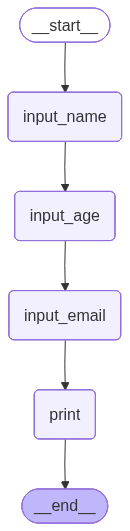

In [31]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

* 4) Graph 실행


In [32]:
# 4. 실행
graph.invoke({})

이름을 입력하세요: user1
나이를 입력하세요: 28
이메일을 입력하세요: ㄴㅇ@

[유저 프로필 정보]
이름: user1
나이: 28
이메일: ㄴㅇ@


{'name': 'user1', 'age': 28, 'email': 'ㄴㅇ@'}

### (3) 실습2

* 요구사항
    * 노드 2개를 만들고, START → node_1 → node_2 → END 흐름으로 연결하시오.
    * node_1은 다음을 수행:
        * "score"에 10을 추가
        * "log"에 "node_1 completed"를 추가

    * node_2는 다음을 수행:
        * "score"에 5를 추가
        * "log"에 "node_2 completed"를 추가

    * 각 node_1, node_2의 실행 결과(state)를 출력하시오.
    * 최종 상태를 출력하시오.



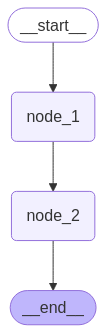

* State 정의

In [33]:
class State(TypedDict):
    username: str
    score: int
    log: list[str]

* Node 정의

In [34]:
# node_1: 점수 +10, 로그 기록
def node_1(state: State):
    state["score"] += 10
    state["log"].append("node_1 completed")
    print("node_1 실행 후 상태:", state)
    return state

# node_2: 점수 +5, 로그 기록
def node_2(state: State):
    state["score"] += 5
    state["log"].append("node_2 completed")
    print("node_2 실행 후 상태:", state)
    return state

* 그래프 정의

In [35]:
# 그래프 생성
builder = StateGraph(State)

# 노드 등록
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# 엣지 연결: START → node_1 → node_2 → END
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# 그래프 컴파일
graph = builder.compile()

* 그래프 시각화

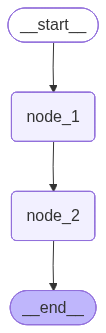

In [36]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

* Graph 실행

In [37]:
# 실행
initial_state = {
    "username": "student01",
    "score": 0,
    "log": []
}

result = graph.invoke(initial_state)
print("최종 결과:", result)

node_1 실행 후 상태: {'username': 'student01', 'score': 10, 'log': ['node_1 completed']}
node_2 실행 후 상태: {'username': 'student01', 'score': 15, 'log': ['node_1 completed', 'node_2 completed']}
최종 결과: {'username': 'student01', 'score': 15, 'log': ['node_1 completed', 'node_2 completed']}


## 4.Graph 구축②: Routing

* workflow에서 Routing은 매우 중요합니다. *Routing*(라우팅) 은 특정 입력에 따라 서로 다른 경로를 선택하여 실행 흐름을 제어하는 기능입니다.
* 이를 통해 사용자의 입력이나 특정 조건에 따라 서로 다른 노드를 실행할 수 있습니다.

### (1) Conditional Edge

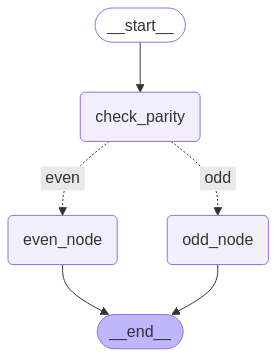

#### 1) State 정의

In [38]:
class State(TypedDict):
    number: int
    result: str

#### 2) Node 정의

In [39]:
# 노드: 짝/홀수 판별
def check_parity(state: State):
    print(f"check_parity: 입력된 숫자 = {state['number']}")
    return state  # 판단만 하고, 실제 처리는 다음 노드에서 함

# 짝수 노드
def even_node(state: State):
    print("짝수입니다!")
    state["result"] = "짝수입니다!"
    return state

# 홀수 노드
def odd_node(state: State):
    print("홀수입니다!")
    state["result"] = "홀수입니다!"
    return state

#### 3) 그래프 정의

In [40]:
# 그래프 생성
builder = StateGraph(State)

# 노드 등록
builder.add_node("check_parity", check_parity)
builder.add_node("even_node", even_node)
builder.add_node("odd_node", odd_node)

# 조건 분기 연결
def parity_condition(state: State):
    return "even" if state["number"] % 2 == 0 else "odd"

builder.add_conditional_edges("check_parity", parity_condition,
                              {"even": "even_node", "odd": "odd_node"}
                              )

# 나머지 연결
builder.add_edge(START, "check_parity")
builder.add_edge("even_node", END)
builder.add_edge("odd_node", END)

# 그래프 컴파일
graph = builder.compile()

* 그래프 시각화

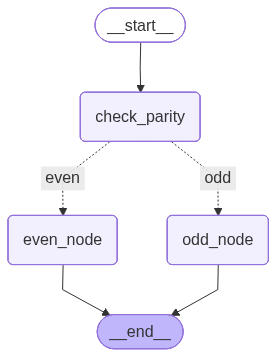

In [41]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) Graph 실행

In [42]:
state = {"number": 7, "result": ""}
result = graph.invoke(state)
print("최종 결과:", result)

check_parity: 입력된 숫자 = 7
홀수입니다!
최종 결과: {'number': 7, 'result': '홀수입니다!'}


### (2) 실습1

* check_score: 분기 기준 판단만 하고 상태는 변경하지 않음
* pass_node: "result"에 "합격" 저장
* fail_node: "result"에 "불합격" 저장

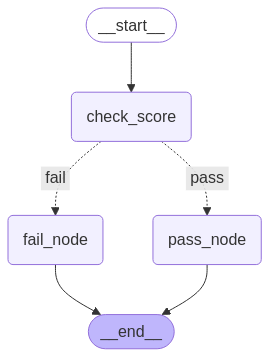

#### 1) State 정의

In [43]:
class State(TypedDict):
    username: str
    score: int
    result: str

#### 2) Node 정의

In [44]:
# check_score 노드 (조건 판단만 함)
def check_score(state: State):
    print(f"점수 확인: {state['score']}")
    return state

# 합격 노드
def pass_node(state: State):
    print("합격 처리")
    state["result"] = "합격"
    return state

# 불합격 노드
def fail_node(state: State):
    print("불합격 처리")
    state["result"] = "불합격"
    return state

#### 3) 그래프 정의

In [45]:
# 그래프 구성
builder = StateGraph(State)

builder.add_node("check_score", check_score)
builder.add_node("pass_node", pass_node)
builder.add_node("fail_node", fail_node)

# 조건 함수 정의
def decide_pass_fail(state: State):
    return "pass" if state["score"] >= 60 else "fail"

builder.add_conditional_edges("check_score",
                              decide_pass_fail,
                              {"pass": "pass_node", "fail": "fail_node"}
                              )

# 나머지 연결
builder.add_edge(START, "check_score")
builder.add_edge("pass_node", END)
builder.add_edge("fail_node", END)

graph = builder.compile()

* 그래프 시각화

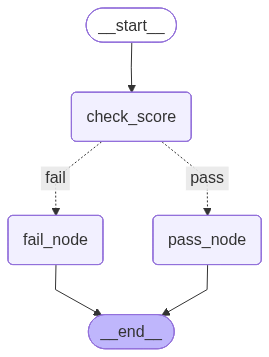

In [46]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) Graph 실행

In [47]:
initial_state = {"username": "student01", "score": 75, "result": ""}

result = graph.invoke(initial_state)
print("최종 상태:", result)

점수 확인: 75
합격 처리
최종 상태: {'username': 'student01', 'score': 75, 'result': '합격'}


### (3) 실습2

* 목표 : 사용자의 감정을 판단해 다른 응답을 출력하는 조건 분기 라우팅 그래프 만들기

* 문제 설명 : 사용자로부터 입력받은 감정(문자열 "happy", "sad", "angry")에 따라 다른 노드를 호출하는 그래프를 만드시오.

* 조건:
    * 상태는 {"emotion": str, "response": str}
    * router 노드가 emotion 값을 기반으로 "happy", "sad", "angry" 중 하나의 노드로 분기
    * 각 감정 노드는 감정에 맞는 위로 또는 축하 메시지를 출력

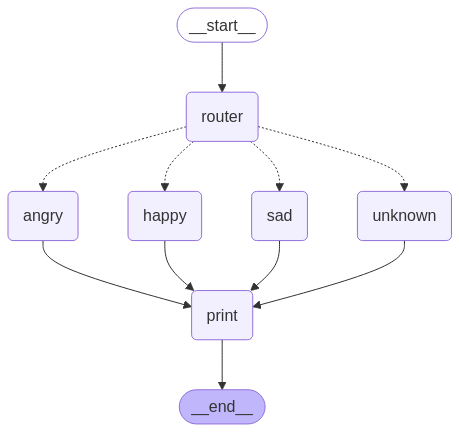

#### 1) State 정의

In [48]:
class EmotionState(TypedDict):
    emotion: str
    response: str

#### 2) Node 정의

In [49]:
# 2. 노드
def router(state: EmotionState) -> EmotionState:
    return state

def respond_happy(state: EmotionState) -> EmotionState:
    state["response"] = "기분이 좋다니 저도 기쁘네요! 😊"
    return state

def respond_sad(state: EmotionState) -> EmotionState:
    state["response"] = "무슨 일이 있었나요? 힘내세요. 💙"
    return state

def respond_angry(state: EmotionState) -> EmotionState:
    state["response"] = "화를 푸는 데 도움이 되고 싶어요. 💨"
    return state

def respond_unknown(state: EmotionState) -> EmotionState:
    state["response"] = "그 감정은 아직 잘 모르겠어요... 🤔"
    return state

# 3. 출력 노드
def print_response(state: EmotionState) -> EmotionState:
    print(f"\n[챗봇 응답]: {state['response']}")
    return state

#### 3) 그래프 정의

In [50]:
# 4. 라우터 정의
def emotion_router(state: EmotionState) -> str:
    emotion = state["emotion"].lower()
    if emotion == "happy":
        return "happy"
    elif emotion == "sad":
        return "sad"
    elif emotion == "angry":
        return "angry"
    else:
        return "unknown"

# 5. 그래프 구축
builder = StateGraph(EmotionState)

# router 노드 추가
builder.add_node("router", router)

builder.add_node("happy", respond_happy)
builder.add_node("sad", respond_sad)
builder.add_node("angry", respond_angry)
builder.add_node("unknown", respond_unknown)
builder.add_node("print", print_response)

# 라우팅 분기
builder.add_conditional_edges("router", emotion_router, {
    "happy": "happy",
    "sad": "sad",
    "angry": "angry",
    "unknown": "unknown"
})

# 각 감정 응답 노드 → print → END
# builder.add_edge(START, 'router')
for emotion_node in ["happy", "sad", "angry", "unknown"]:
    builder.add_edge(emotion_node, "print")
builder.add_edge("print", END)

# 시작점 설정
builder.set_entry_point("router")

# 컴파
graph = builder.compile()

* 그래프 시각화

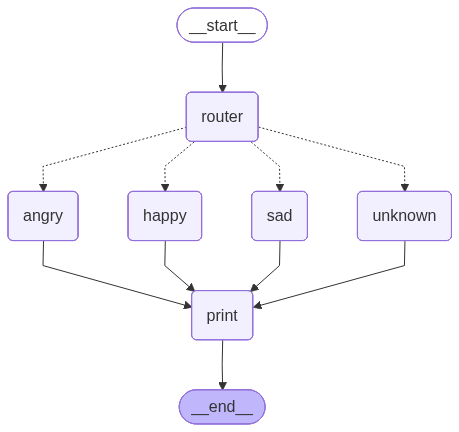

In [51]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) Graph 실행

In [52]:
user_input = input("당신의 현재 감정은 무엇인가요? (happy, sad, angry): ")
graph.invoke({"emotion": user_input})

당신의 현재 감정은 무엇인가요? (happy, sad, angry): sad

[챗봇 응답]: 무슨 일이 있었나요? 힘내세요. 💙


{'emotion': 'sad', 'response': '무슨 일이 있었나요? 힘내세요. 💙'}

## 5.Graph 구축③: Reflection



### (1) reflect_node

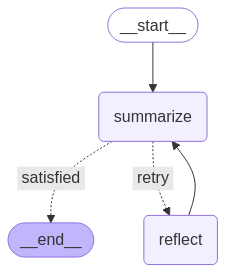

#### 1) State 정의

* input: 사용자의 입력
* summary: 요약된 결과 (간단하게 하드코딩 처리)
* is_satisfied: 결과에 만족했는지 여부
* log: 상태 변화를 기록하는 로그

In [53]:
class State(TypedDict):
    input: str
    summary: str
    is_satisfied: bool
    log: list[str]

#### 2) Node 정의

In [54]:
# 요약 노드: 간단히 결과 요약 + 만족 여부 결정
def summary_node(state: State):
    state["summary"] += " → 요약됨"
    state["log"].append("요약 수행")

    # 만족 여부 판단 (2회 이상 요약되면 만족했다고 가정)
    if state["summary"].count("요약됨") >= 2:
        state["is_satisfied"] = True
    else:
        state["is_satisfied"] = False
    print(state)
    return state

# 반추 노드: 추가 아이디어 도출 시도 (다시 생각해보기)
def reflect_node(state: State):
    state["log"].append("반추 수행")
    state["summary"] += " → 다시 생각해봄"
    print(state)
    return state

#### 3) 그래프 정의

In [55]:
# 그래프 구성
builder = StateGraph(State)
builder.add_node("summarize", summary_node)
builder.add_node("reflect", reflect_node)

# 흐름 정의
builder.add_edge(START, "summarize")

# 조건 분기: 만족 여부에 따라 흐름 결정
def check_satisfaction(state: State):
    return "satisfied" if state["is_satisfied"] else "retry"

builder.add_conditional_edges("summarize", check_satisfaction,
                              {"satisfied": END, "retry": "reflect"})

# 반추 후 → 요약 다시 시도 (루프)
builder.add_edge("reflect", "summarize")

# 컴파일
graph = builder.compile()

* 그래프 시각화

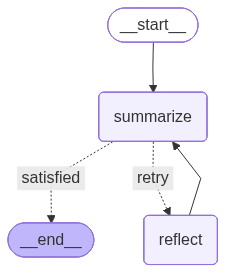

In [56]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) Graph 실행

In [57]:
# 실행
initial_state = {"input": "오늘 하루 요약해줘", "summary": "", "is_satisfied": False, "log": [] }

result = graph.invoke(initial_state)
print("최종 상태:")
print(result)

{'input': '오늘 하루 요약해줘', 'summary': ' → 요약됨', 'is_satisfied': False, 'log': ['요약 수행']}
{'input': '오늘 하루 요약해줘', 'summary': ' → 요약됨 → 다시 생각해봄', 'is_satisfied': False, 'log': ['요약 수행', '반추 수행']}
{'input': '오늘 하루 요약해줘', 'summary': ' → 요약됨 → 다시 생각해봄 → 요약됨', 'is_satisfied': True, 'log': ['요약 수행', '반추 수행', '요약 수행']}
최종 상태:
{'input': '오늘 하루 요약해줘', 'summary': ' → 요약됨 → 다시 생각해봄 → 요약됨', 'is_satisfied': True, 'log': ['요약 수행', '반추 수행', '요약 수행']}


### (2) 실습1

* 사용자가 오타가 있는 문장을 입력했을 때,
    * 에이전트가 그것을 수정 → 검사 → 수정 → 검사…
    * 하면서 **"이제 충분히 고쳐졌다고 판단되면 종료"**하는 구조를 만든다.

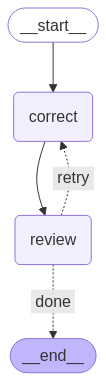

#### 1) State 정의

In [58]:
class State(TypedDict):
    original: str         # 원본 입력
    corrected: str        # 현재까지 수정된 문장
    satisfied: bool       # 수정이 완료되었는가?
    log: list[str]        # 각 단계의 기록

#### 2) Node 정의

* 노드 구성
    * correct: 오타 교정 시도 (문장 끝에 "✔" 추가)
    * review: 수정 결과를 검사 → 교정이 2번 이상 이루어졌으면 만족 상태로 판단



In [59]:
# 오타 교정 시뮬레이션 노드
def correct(state: State):
    if not state["corrected"]:
        state["corrected"] = state["original"]
    state["corrected"] += "✔"
    state["log"].append("문장 교정 실행")
    print(state)
    return state

# 교정 결과 리뷰
def review(state: State):
    fix_count = state["corrected"].count("✔")
    if fix_count >= 2:
        state["satisfied"] = True
        state["log"].append("교정 결과에 만족함")
    else:
        state["satisfied"] = False
        state["log"].append("추가 교정이 필요함")

    print(state)
    return state

#### 3) 그래프 정의

In [60]:
# 그래프 구성

# 1.초기화
builder = StateGraph(State)

# 2.노드추가
builder.add_node("correct", correct)
builder.add_node("review", review)

# 3.연결!
# 3.1 edge
builder.add_edge(START, "correct")
builder.add_edge("correct", "review")

# 3.2 conditaional edge
def decide_next(state: State):
    return "done" if state["satisfied"] else "retry"

builder.add_conditional_edges("review", decide_next, {"done": END, "retry": "correct"} )

# 4. 컴파일
graph = builder.compile()

* 그래프 시각화

In [61]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) Graph 실행

In [62]:
# 실행
initial_state = {"original": "나는 피자을 좋아해", "corrected": "", "satisfied": False,"log": [] }

result = graph.invoke(initial_state)
print("최종 상태:", result)

{'original': '나는 피자을 좋아해', 'corrected': '나는 피자을 좋아해✔', 'satisfied': False, 'log': ['문장 교정 실행']}
{'original': '나는 피자을 좋아해', 'corrected': '나는 피자을 좋아해✔', 'satisfied': False, 'log': ['문장 교정 실행', '추가 교정이 필요함']}
{'original': '나는 피자을 좋아해', 'corrected': '나는 피자을 좋아해✔✔', 'satisfied': False, 'log': ['문장 교정 실행', '추가 교정이 필요함', '문장 교정 실행']}
{'original': '나는 피자을 좋아해', 'corrected': '나는 피자을 좋아해✔✔', 'satisfied': True, 'log': ['문장 교정 실행', '추가 교정이 필요함', '문장 교정 실행', '교정 결과에 만족함']}
최종 상태: {'original': '나는 피자을 좋아해', 'corrected': '나는 피자을 좋아해✔✔', 'satisfied': True, 'log': ['문장 교정 실행', '추가 교정이 필요함', '문장 교정 실행', '교정 결과에 만족함']}


### (3) 실습2

* 수 맞히기 게임
    * 랜덤 숫자(1~10)를 입력받아 맞힐 때까지 계속 추측하는 루프 구조 만들기
        * 노드의 실행 결과에 따라 같은 노드를 한 번 더 실행하거나,
        * 특정 조건을 만족하면 종료하거나 다른 노드로 이동할 수 있음
        * 흔히 쓰는 구조
            * judge 노드가 "retry" vs "next" 판단
            * → "retry"면 앞 노드로 되돌아가서 루프
            * → "next"면 다음 노드로 진행



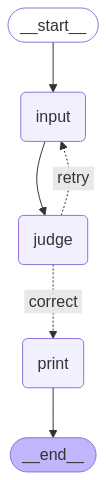

In [63]:
import random

#### 1) State 정의

In [64]:
# 1. 상태 정의
class GuessState(TypedDict, total=False):
    guess: int
    answer: int
    result: str
    # next: str

#### 2) Node 정의

In [65]:
# 2. 사용자 입력 노드
def input_guess(state: GuessState) -> GuessState:
    guess = int(input("1부터 10 사이의 숫자를 맞혀보세요: "))
    state["guess"] = guess
    return state

# 3. 판별 노드 (실제 상태 변경 포함)
def judge_node(state: GuessState) -> GuessState:
    if state["guess"] == state["answer"]:
        state["result"] = "정답"
        # state["next"] = "correct"
    else:
        print("틀렸습니다! 다시 시도해보세요.")
        state["result"] = "오답"
    return state

# 4. reflect
def check_correct(state: GuessState) -> str:
    if state["result"] == "정답" :
        return "correct"
    else:
        return "retry"

# 5. 출력 노드
def print_result(state: GuessState) -> GuessState:
    print(f"\n[결과] {state['result']}")
    return state


#### 3) 그래프 정의

In [66]:
# 6. 그래프 구축
builder = StateGraph(GuessState)

builder.add_node("input", input_guess)
builder.add_node("judge", judge_node)
builder.add_node("print", print_result)

# 조건 분기 추가
builder.add_conditional_edges("judge", check_correct, {
    "retry": "input",
    "correct": "print"
})

builder.add_edge("input", "judge")
builder.add_edge("print", END)
builder.set_entry_point("input")

graph = builder.compile()

* 그래프 시각화

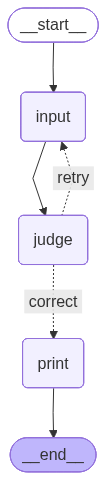

In [67]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) Graph 실행

In [69]:
# 7. 실행
answer = random.randint(1, 10)
graph.invoke({"answer": answer})

1부터 10 사이의 숫자를 맞혀보세요: 1
틀렸습니다! 다시 시도해보세요.
1부터 10 사이의 숫자를 맞혀보세요: 2
틀렸습니다! 다시 시도해보세요.
1부터 10 사이의 숫자를 맞혀보세요: 3
틀렸습니다! 다시 시도해보세요.
1부터 10 사이의 숫자를 맞혀보세요: 4
틀렸습니다! 다시 시도해보세요.
1부터 10 사이의 숫자를 맞혀보세요: 5
틀렸습니다! 다시 시도해보세요.
1부터 10 사이의 숫자를 맞혀보세요: 6
틀렸습니다! 다시 시도해보세요.
1부터 10 사이의 숫자를 맞혀보세요: 7
틀렸습니다! 다시 시도해보세요.
1부터 10 사이의 숫자를 맞혀보세요: 8

[결과] 정답


{'guess': 8, 'answer': 8, 'result': '정답'}